<a href="https://colab.research.google.com/github/olympiasau/A01-data-wrangling/blob/main/A1_9_2_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Olympia Sauerwein

**Date:** 9/2/26

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


    Host Id Host Since                                Name Neighbourhood   \
0   5162530        NaN     1 Bedroom in Prime Williamsburg       Brooklyn   
1  33134899        NaN     Sunny, Private room in Bushwick       Brooklyn   
2  39608626        NaN                Sunny Room in Harlem      Manhattan   
3       500  6/26/2008  Gorgeous 1 BR with Private Balcony      Manhattan   
4       500  6/26/2008            Trendy Times Square Loft      Manhattan   

  Property Type  Review Scores Rating (bin)        Room Type  Zipcode  Beds  \
0     Apartment                         NaN  Entire home/apt  11249.0   1.0   
1     Apartment                         NaN     Private room  11206.0   1.0   
2     Apartment                         NaN     Private room  10032.0   1.0   
3     Apartment                         NaN  Entire home/apt  10024.0   3.0   
4     Apartment                        95.0     Private room  10036.0   3.0   

   Number of Records  Number Of Reviews Price  Review Scores R

<Axes: >

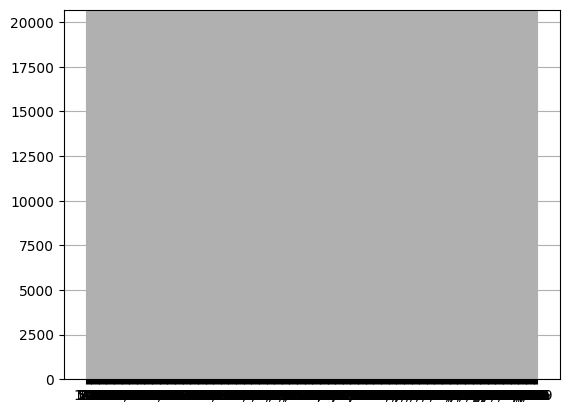

In [12]:
#QUESTION 1 PART 1
import numpy as np
import pandas as pd

# import the data
df_airbnb = pd.read_csv("/content/airbnb_hw.csv")

# view the data
print(df_airbnb.head())
price = 'Price'
print(df_airbnb[price].unique(), '\n')
print(df_airbnb[price].value_counts(), '\n')
df_airbnb[price].hist()

# get rid of the commas to clean
df_airbnb[price] = df_airbnb[price].str.replace(',', '', regex=True)

# convert to numeric so the price is represented as a number
df_airbnb[price] = pd.to_numeric(df_airbnb[price], errors='coerce')

# check that there are no missing values
df_airbnb['price_nan'] = df_airbnb[price].isnull()
print('Total missings:\n', sum(df_airbnb['price_nan']), '\n')

# generate histogram to confirm data
print('After coercion:\n', df_airbnb[price].describe(), '\n')
df_airbnb[price].hist(bins=50)

In [16]:
#QUESTION 1 PART 2

# import data
df_mnpolice = pd.read_csv("/content/mn_police_use_of_force.csv")

# view the data
var = 'subject_injury'
print(df_mnpolice[var].unique(), '\n')
print(df_mnpolice[var].value_counts(dropna=False), '\n')

# still missing 9848 answers!


[nan 'No' 'Yes'] 

subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64 



In [18]:
# confirm blank cells are noted as missing/nan
df_mnpolice['subject_injury_nan'] = df_mnpolice[var].isnull()
print('Total missing:\n', sum(df_mnpolice['subject_injury_nan']), '\n')

# cross-tabluate  subject_injury with force_type
ct = pd.crosstab(df_mnpolice['force_type'], df_mnpolice[var], dropna=False)
print(ct, '\n')

# it seems data is most likely to be missing when there is bodily force,
# chemical irritant, less lethal, maximal restrainst techniques, or tasers
# involved.

Total missing:
 9848 

subject_injury                 No   Yes   NaN
force_type                                   
Baton                           0     2     2
Bodily Force                 1093  1286  7051
Chemical Irritant             131    41  1421
Firearm                         2     0     0
Gun Point Display              33    44    27
Improvised Weapon              34    40    74
Less Lethal                     0     0    87
Less Lethal Projectile          1     2     0
Maximal Restraint Technique     0     0   170
Police K9 Bite                  2    44    31
Taser                         150   172   985 



In [20]:
# QUESTION 2

# import data
sharks = pd.read_excel('/content/drive/MyDrive/data/GSAF5.xls', sheet_name='Sheet1-GSAF')

# view the data
print("df.shape:")
print(sharks.shape, '\n')
print("df.dtypes:")
print(sharks.dtypes, '\n')
sharks.head()

df.shape:
(7117, 23) 

df.dtypes:
Date               object
Year              float64
Type               object
Country            object
State              object
Location           object
Activity           object
Name               object
Sex                object
Age                object
Injury             object
Fatal Y/N          object
Time               object
Species            object
Source             object
pdf                object
href formula       object
href               object
Case Number        object
Case Number.1      object
original order    float64
Unnamed: 21        object
Unnamed: 22        object
dtype: object 



,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,...,Tiger Shark,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,Large shark,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,...,Bull shark 2.5m (8.2 ft),Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,1.5m (5ft) Blue shark,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,Great White Shark,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Columns after dropping empty ones: (7117, 22) 

count    7115.000000
mean     1936.549122
std       269.943193
min         0.000000
25%      1948.000000
50%      1987.000000
75%      2010.000000
max      2026.000000
Name: Year, dtype: float64 

Attacks since 1940: (5581, 22) 



<Axes: >

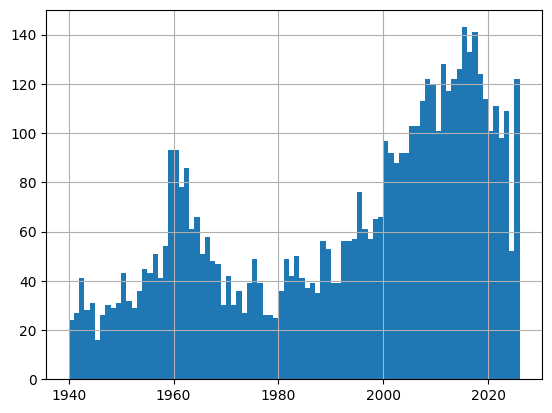

In [47]:
# remove columns that don't contain data (columns 21 and 22)
keep_cols = [c for c in sharks.columns if c not in ['Unnamed: 21', 'Unnamed: 22']]
sharks = sharks.loc[:, keep_cols]
print('Columns after dropping empty ones:', sharks.shape, '\n')

# check year variable
Year = 'Year'
print(sharks[Year].describe(), '\n')
#range technically starts at year 0 and spans until this year, 2026

# filter to attacks since 1940 and then print histogram
df_recent = sharks[sharks[Year] >= 1940]
print('Attacks since 1940:', df_recent.shape, '\n')
df_recent[Year].hist(bins=int(df_recent[Year].max() - df_recent[Year].min()))
# looks like shark attacks peaked in 1960 and then again in 2018; they have gone
# down since then until this year where they almost reached the peak in 2018.


In [30]:
# check age variable
Age = 'Age'
print('Before coercion:\n', sharks[Age].describe(), '\n')

Before coercion:
 count     4123
unique     252
top         16
freq        92
Name: Age, dtype: int64 



After coercion:
 count    3948.000000
mean       28.197315
std        14.697518
min         1.000000
25%        17.000000
50%        24.000000
75%        37.000000
max        87.000000
Name: Age, dtype: float64 

Total missing:
 3169 



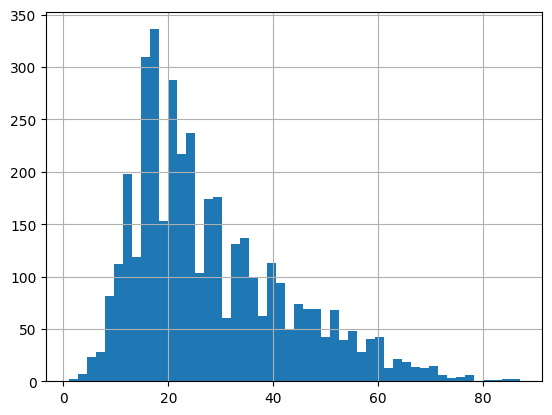

In [38]:
# clean age variable by converting to numeric
sharks[Age] = pd.to_numeric(sharks[Age], errors='coerce')
sharks['age_nan'] = sharks[Age].isnull()

# histrogram with results
print('After coercion:\n', sharks[Age].describe(), '\n')
sharks[Age].hist(bins=50)
print('Total missing:\n', sum(sharks['age_nan']), '\n')

In [34]:
# clean sex variable
Sex = 'Sex'
print(sharks[Sex].value_counts(dropna=False), '\n')

sharks[Sex] = sharks[Sex].replace({
    'M ': 'M', ' M': 'M', 'm': 'M',
    'F ': 'F',
    '?': np.nan, 'N': np.nan, '.': np.nan,
    'M F': np.nan, 'lli': np.nan, 'M x 2': np.nan
})
print(sharks[Sex].value_counts(dropna=False), '\n')

prop_male = sum(sharks[Sex] == 'M') / sharks.shape[0]
print('Proportion male:', round(prop_male, 3), '\n')

# 0.803 of people attacked by sharks are male.

Sex
M      5713
F       818
NaN     586
Name: count, dtype: int64 

Sex
M      5713
F       818
NaN     586
Name: count, dtype: int64 

Proportion male: 0.803 



In [46]:
# clean type of shark attack data by first identifying what is there
Type = 'Type'
print(sharks[Type].value_counts(dropna=False), '\n')

# replacing variations of unprovoked with the same name
sharks[Type] = sharks[Type].replace(['UNprovoked', 'unprovoked', 'unprovoked'],
                                    'Unprovoked')
# replacing variations of provoked with the same name
sharks[Type] = sharks[Type].replace(['provoked', ' Provoked'], 'Provoked')

# replacing other possibilities with unknown
sharks[Type] = sharks[Type].replace(
    ['Questionable', 'Watercraft', 'Sea Disaster', '?',
     'Unconfirmed', 'Unverified', 'Invalid', 'Under investigation', 'Boat', 'NaN'],
    'Unknown'
)

sharks[Type] = sharks[Type].fillna('Unknown')

# find proportion of unprovoked attacks
print(sharks[Type].value_counts(dropna=False), '\n')

prop_unprovoked = sum(sharks[Type] == 'Unprovoked') / sharks.shape[0]
print('Proportion unprovoked:', round(prop_unprovoked, 3), '\n')

# almost 74% of shark attacks are unprovoked!

Type
Unprovoked    5263
Unknown       1205
Provoked       649
Name: count, dtype: int64 

Type
Unprovoked    5263
Unknown       1205
Provoked       649
Name: count, dtype: int64 

Proportion unprovoked: 0.739 



## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]